# **Bitcoin's Demand Analysis**

## Purpose

This project aims to analyze on-chain Bitcoin data to gain a deeper understanding of Bitcoin demand over time. By examining key metrics such as the number of active addresses and the total transaction count alongside Bitcoin's price, we can uncover valuable insights into market dynamics. These two metrics serve as proxies for estimating Bitcoin demand, showcasing a clear growth trend over time. As Bitcoin's adoption increases, these metrics provide a tangible measure of user engagement and transaction activity on the network.

## Background and Theory

### On-Chain Metrics

On-chain metrics are crucial for understanding the health and usage of a blockchain network. They are derived directly from the blockchain data and offer insights into user activity and network performance. For Bitcoin, two critical on-chain metrics are:

- **Active Addresses**: This metric counts the number of unique addresses participating in transactions as either sender or receiver. An increasing number of active addresses typically indicates growing user interest and adoption of Bitcoin.

- **Transaction Count**: This metric represents the total number of transactions processed by the Bitcoin network. Higher transaction counts can indicate increased network activity and demand for using Bitcoin as a medium of exchange.

### LOESS Regression

LOESS (Locally Estimated Scatterplot Smoothing) is a non-parametric regression method that fits multiple regressions in localized subsets of the data to create a smooth curve through the data points. It is particularly useful for time series data to highlight trends by reducing noise. The `statsmodels` library in Python provides a straightforward implementation of LOESS.

### Logarithmic Scale

When analyzing Bitcoin's price over time, it's beneficial to use a logarithmic scale. The log scale is especially useful for data with exponential growth patterns, like Bitcoin's price, because it allows us to see percentage changes more clearly and compare periods of different magnitudes more effectively.

## What I Did

### 1. Data Loading
The first step involved loading historical Bitcoin data from a CSV file. This data includes timestamps, the number of active addresses, transaction counts, and Bitcoin's USD price. The data is loaded into a pandas DataFrame for easy manipulation and analysis.

### 2. Data Cleaning and Preparation
To ensure the accuracy of the analysis, rows with missing price values were removed. The relevant columns (`time`, `AdrActCnt`, `TxCnt`, `PriceUSD`) were selected and the time column was set as the index for easy time series manipulation.

### 3. Applying LOESS Regression
LOESS regression was applied to the active addresses and transaction count columns. This smoothing technique helps in visualizing the underlying trends by reducing noise in the time series data. The `add_loess` function was created to perform this smoothing and return a smoothed series.

### 4. Generating Graphs
A combined graph was generated to display:
- **Bitcoin's Price** in logarithmic scale on the left y-axis.
- **Number of Active Addresses** on the first right y-axis.
- **Total Transaction Count** on the second right y-axis.

The smoothed LOESS curves for active addresses and transaction counts were also plotted to highlight the trends over time.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys

import sys, os
_base = os.getcwd()
while _base and not os.path.isdir(os.path.join(_base, 'functions')):
    _parent = os.path.dirname(_base)
    if _parent == _base: break
    _base = _parent
if os.path.abspath(_base) not in sys.path:
    sys.path.insert(0, os.path.abspath(_base))
from functions.functions_demand import load_btc_data, generate_plot

you are using nologin method, data you access may be limited


✅ BTC data fetched from CoinMetrics: 6341 rows (last: 2026-05-14)


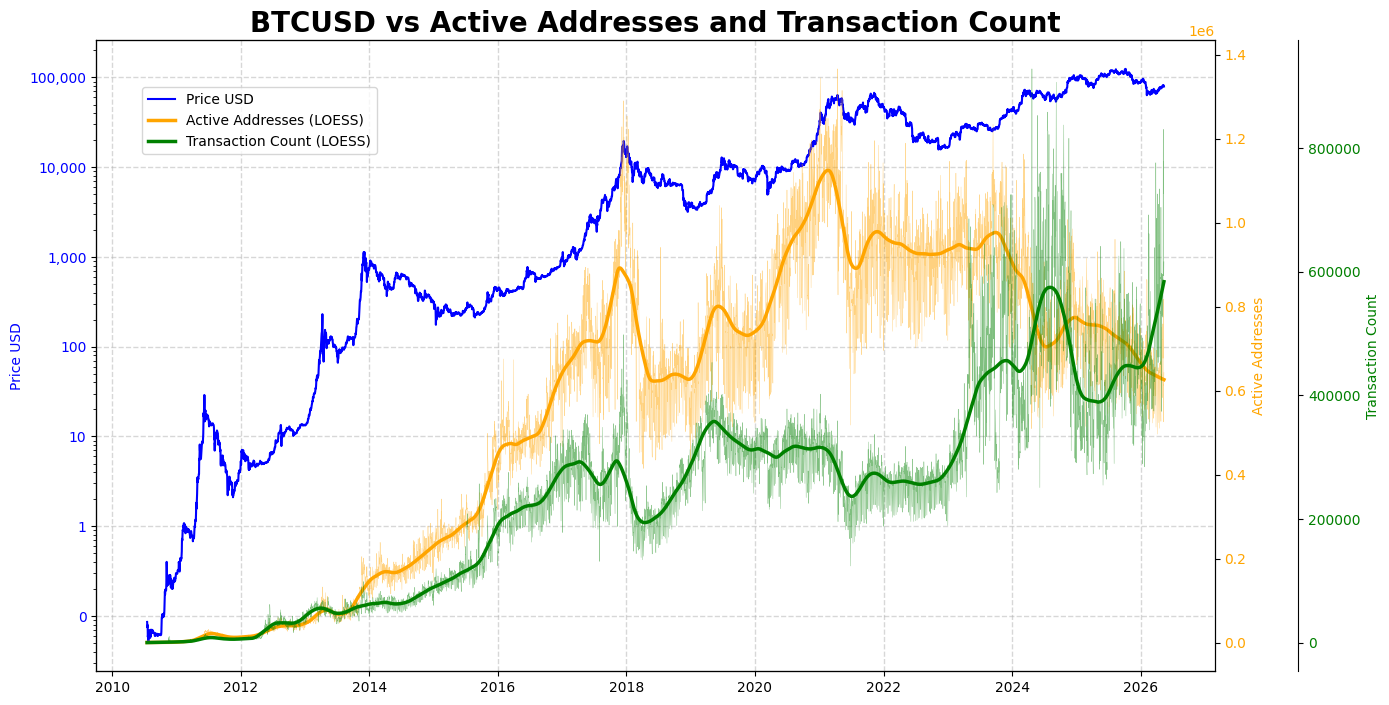

In [2]:
generate_plot(load_btc_data())

The significant decline in Bitcoin's active addresses began in mid-April 2024, coinciding with the launch of the Runes protocol on the Bitcoin halving block. This new protocol, which claims to be a more efficient method for introducing fungible tokens on Bitcoin, quickly gained traction and now accounts for 60% of daily transactions. Runes utilize the OP_RETURN field, requiring less blockspace than previous protocols like Inscriptions and BRC-20 tokens. The shift to Runes has led to a reduction in unique active addresses, as it often reuses addresses for multiple transactions. Consequently, while overall transaction counts remain high, the number of unique active addresses has decreased significantly, creating a divergence from historical trends of network activity.